<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-17-feature-scaling-norm-std?scriptVersionId=339858546" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🤖 ML 17 — Feature Scaling: Normalization & Standardization

### **Master Normalization & Standardization for Machine Learning.**

---


# 🚀 Introduction

In many Machine Learning problems, features can have completely different scales. For example, one feature might represent **age (20–80)** while another represents **salary (20,000–500,000)**. Models that rely on distance or gradient optimization can become biased toward larger-valued features if the data isn't properly scaled.

In this notebook, you'll learn **Feature Scaling**—an essential preprocessing step that transforms numerical features into comparable ranges without changing the underlying information. You'll explore the two most widely used scaling techniques:

* 📏 **Normalization (Min-Max Scaling)** – scales values to a fixed range, usually **0 to 1**.
* 📊 **Standardization (Z-Score Scaling)** – transforms data to have a **mean of 0** and a **standard deviation of 1**.

By the end of this notebook, you'll understand **when to use each technique, how to implement them with Scikit-learn, and why feature scaling is crucial for building accurate and efficient Machine Learning models.** 🚀

<div align="center">
    <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQzoZo606dEENqPU8nfSK64ejJ5roYx9cKeaiO67JLqSQ&s=10" width=500>
    <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcScPCB7aIIdU1_aiE_SL4cTQWuOcB5LjUg-rrlz9oiUTQ&s=10" width=500>
</div>


---
# 📦 Importing Required Libraries

We'll import the essential libraries needed for data manipulation, visualization, and feature scaling throughout this notebook.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

---

# 📊 Part 1 — Standardization

## 1. Reading Data

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ahmedfakhar123/customer-purchase-prediction-dataset/Social_Network_Ads.csv")
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


## 2. Train test split

In [3]:
# Extracting Features
X = df[["Age", "EstimatedSalary"]]

# Setting Target
y = df["Purchased"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((280, 2), (120, 2))

## 3. Scaling Data

In [5]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

scale.fit(X_train)

X_train_scaled = pd.DataFrame(scale.transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scale.transform(X_test), columns=X_test.columns)

In [6]:
X_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [7]:
X_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [8]:
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [9]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


## 4. Effect of Scaling

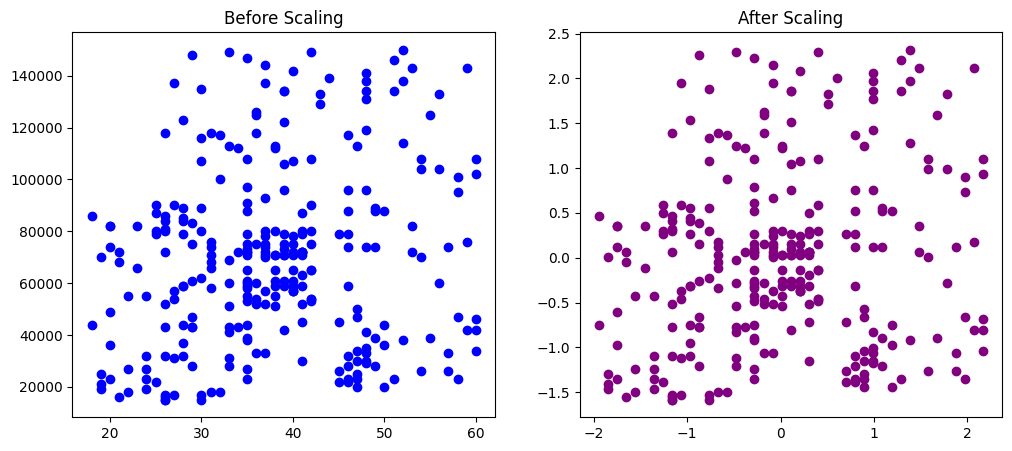

In [10]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before Scaling
ax1.scatter(X_train["Age"], X_train["EstimatedSalary"], color="blue")
ax1.set_title("Before Scaling")

# After Scaling
ax2.scatter(X_train_scaled["Age"], X_train_scaled["EstimatedSalary"], color="purple")
ax2.set_title("After Scaling")

plt.show()

## 5. Comparison of Distributions

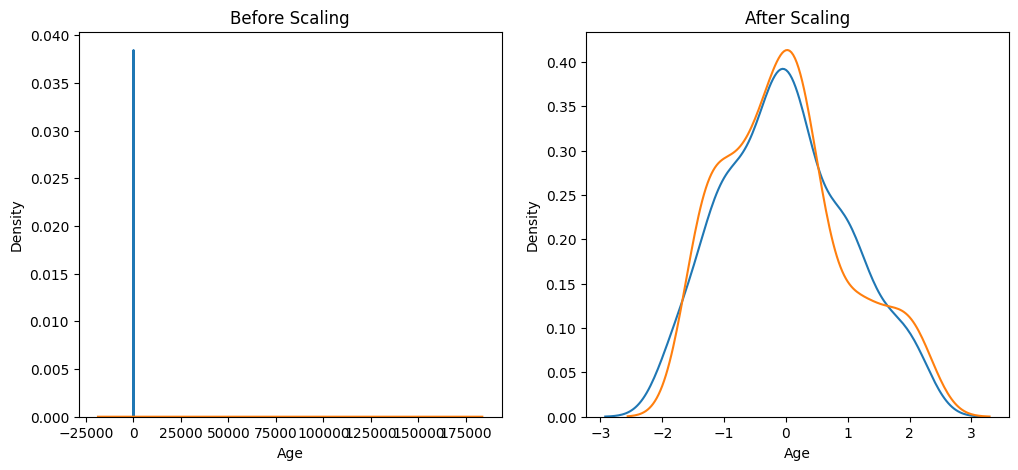

In [11]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train["Age"], ax=ax1)
sns.kdeplot(X_train["EstimatedSalary"], ax=ax1)

# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Age"], ax=ax2)
sns.kdeplot(X_train_scaled["EstimatedSalary"], ax=ax2)

plt.show()

## 6. Why scaling is important?

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model_scaled = LogisticRegression()

model.fit(X_train, y_train)
model_scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [13]:
y_pred = model.predict(X_test)
y_pred_scaled = model_scaled.predict(X_test_scaled)

In [14]:
from sklearn.metrics import accuracy_score

print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


## 7. Effect of Outlier